# 14장 실습 — 양자화·액션 청킹·비동기 실행

13장은 인식 단계가 예산을 지배하고, 배경 부하가 걸리면 계산이 한 주기를 넘는다는 것을 보였다. 이 노트북은 그 지연을 다루는 세 기법을 이 시스템에 얹는다.

| 기법 | 건드리는 것 | 기대 |
|---|---|---|
| 양자화 | 계산 시간 | 인식을 빠르게 해 한 주기 안으로 |
| 액션 청킹 | 추론 횟수 | 한 번 추론으로 H 스텝을 낸다 |
| 비동기 실행 | 지연이 행동에 닿는 방식 | 실행하는 동안 다음 묶음을 계산한다 |

4권은 이 기법들을 따로 쟀다. 여기서는 **한 시스템에 겹쳐** 얹으며 성공률과 추론 부하를 같이 적는다. 그리고 4권 10장의 규칙 — 비동기 실행에서 묶음 길이 H 는 지연 D 의 두 배 이상이어야 한다(H ≥ 2D) — 이 이 과제에서도 서는지 확인한다.

끝에서 `policy/chunk_v1.pt` 와 `runtime/chunk.json` 을 남긴다. 

In [1]:
%pip install -q mujoco==3.13.0 koreanize-matplotlib

Note: you may need to restart the kernel to use updated packages.


In [2]:
import copy
import time
import unicodedata
import numpy as np
import mujoco
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import koreanize_matplotlib  # noqa: F401


def dw(s):
    return sum(2 if unicodedata.east_asian_width(c) in "WF" else 1
               for c in str(s))


def pad(s, n, right=False):
    gap = " " * max(n - dw(s), 0)
    return gap + str(s) if right else str(s) + gap


def wilson(k, n, z=1.96):
    if n == 0:
        return 0., 0.
    ph = k / n
    d = 1 + z * z / n
    c = ph + z * z / (2 * n)
    h = z * ((ph * (1 - ph) + z * z / (4 * n)) / n) ** .5
    return (c - h) / d, (c + h) / d


RED, GREY, INK = "#E32C24", "#8C8A85", "#1C1C1A"
PINK = "#F3A29D"
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True,
                     "grid.alpha": .25, "axes.spines.top": False,
                     "axes.spines.right": False})
torch.set_num_threads(2)
print("mujoco", mujoco.__version__, "/ torch", torch.__version__)

mujoco 3.13.0 / torch 2.14.0+cu130


In [3]:
XML = '''
<mujoco model="sorting_cell">
  <option timestep="0.004" integrator="implicitfast"/>
  <worldbody>
    <geom name="floor" type="plane" size="3 3 .1"
          friction=".6 .005 .0001"/>
    <body name="part" pos="0 0 .031">
      <freejoint/>
      <geom type="cylinder" size=".03 .03" mass=".25"
            friction=".6 .005 .0001"/>
    </body>
    <body name="pusher" pos="0 0 .03">
      <joint name="px" type="slide" axis="1 0 0"/>
      <joint name="py" type="slide" axis="0 1 0"/>
      <geom type="cylinder" size=".012 .03" mass="4"/>
    </body>
  </worldbody>
  <actuator>
    <velocity joint="px" kv="120"/>
    <velocity joint="py" kv="120"/>
  </actuator>
</mujoco>
'''

EP, GOAL_R, AMAX = 110, .03, .35
SEP, BX = .10, .28                      # 적재함 위치 (m)
MODEL = mujoco.MjModel.from_xml_string(XML)


def bin_xy(k):
    """A형(k=0)은 왼쪽, B형(k=1)은 오른쪽 적재함이다"""
    return np.array([BX, (1 - 2 * k) * SEP])


class Cell:
    """평면 분류 셀 — 부품을 종류에 맞는 칸으로 민다"""

    def __init__(self, n, seed=0, hz=20):
        self.m = MODEL
        self.sub = int(round(1 / hz / self.m.opt.timestep))
        self.n = n
        self.d = [mujoco.MjData(self.m) for _ in range(n)]
        self.g = np.zeros((n, 2))
        self.k = np.zeros(n, int)
        self.t = np.zeros(n, int)
        self.db = np.zeros(n)
        self.dp = np.zeros(n)
        self.rng = np.random.default_rng(seed)
        for i in range(n):
            self.reset(i)

    def reset(self, i):
        d = self.d[i]
        mujoco.mj_resetData(self.m, d)
        bx, by = self.rng.uniform(-.03, .03, 2)
        d.qpos[0:2] = [bx, by]
        d.qpos[2] = .031
        self.k[i] = self.rng.integers(0, 2)
        jit = self.rng.uniform(-.03, .03, 2)
        self.g[i] = bin_xy(self.k[i]) + jit
        b = np.array([bx, by])
        v = self.g[i] - b
        d.qpos[7:9] = b - v / np.linalg.norm(v) * .09
        mujoco.mj_forward(self.m, d)
        self.t[i] = 0
        self.db[i] = np.linalg.norm(d.qpos[0:2] - self.g[i])
        self.dp[i] = np.linalg.norm(d.qpos[7:9] - d.qpos[0:2])

    def obs(self):
        o = np.zeros((self.n, 10), np.float32)
        for i, d in enumerate(self.d):
            b = np.asarray(d.qpos[0:2], float)
            o[i, 0:2] = (self.g[i] - b) * 10.
            o[i, 2:4] = d.qvel[0:2] * 10.
            o[i, 4:6] = (b - d.qpos[7:9]) * 10.
            o[i, 6:8] = d.qvel[6:8] * 10.
            o[i, 8 + self.k[i]] = 1.          # 종류 표시
        return o

    def step(self, a):
        r = np.zeros(self.n, np.float32)
        dn = np.zeros(self.n, np.float32)
        sc = []
        for i, d in enumerate(self.d):
            d.ctrl[:] = np.clip(a[i], -1, 1) * AMAX
            for _ in range(self.sub):
                mujoco.mj_step(self.m, d)
            db = np.linalg.norm(d.qpos[0:2] - self.g[i])
            dp = np.linalg.norm(d.qpos[7:9] - d.qpos[0:2])
            r[i] = (10 * (self.db[i] - db) + 2 * (self.dp[i] - dp)
                    + (.3 if db < GOAL_R else 0.))
            self.db[i], self.dp[i] = db, dp
            self.t[i] += 1
            hit = db < GOAL_R
            if hit or self.t[i] >= EP:
                dn[i] = 1.
                other = bin_xy(1 - self.k[i])
                wrong = np.linalg.norm(d.qpos[0:2] - other) < .06
                sc.append((int(hit), int(wrong), int(self.t[i]),
                           int(self.k[i])))
                self.reset(i)
        return r, dn, sc

In [4]:
class Pert(Cell):
    """배포 조건 — 관측 편향, 제어 지연, 다른 마찰"""

    def __init__(self, n, seed=0, bias=(0., 0.), lat=0, mu=.6):
        self.bias = np.asarray(bias)
        self.lat = lat
        super().__init__(n, seed)
        if mu != .6:
            xml = XML.replace('friction=".6', f'friction="{mu}')
            self.m = mujoco.MjModel.from_xml_string(xml)
            self.sub = int(round(1 / 20 / self.m.opt.timestep))
            self.d = [mujoco.MjData(self.m) for _ in range(n)]
            for i in range(n):
                self.reset(i)
        self.buf = [[np.zeros(2)] * (lat + 1) for _ in range(n)]

    def obs(self):
        o = super().obs()
        o[:, 0:2] -= np.float32(self.bias * 10.)
        o[:, 4:6] += np.float32(self.bias * 10.)
        return o

    def step(self, a):
        if self.lat:
            out = np.empty_like(a)
            for i in range(self.n):
                self.buf[i].append(a[i].copy())
                out[i] = self.buf[i][-1 - self.lat]
            a = out
        return super().step(a)


COND = {"명목": dict(),
        "배포": dict(bias=(.006, -.004), lat=1, mu=.80)}
print("적재함 A", np.round(bin_xy(0), 2))
print("적재함 B", np.round(bin_xy(1), 2))
print("평가 조건:", ", ".join(COND))

적재함 A [0.28 0.1 ]
적재함 B [ 0.28 -0.1 ]
평가 조건: 명목, 배포


In [5]:
class AC(nn.Module):
    def __init__(self, din=10):
        super().__init__()
        self.pi = nn.Sequential(nn.Linear(din, 64), nn.Tanh(),
                                nn.Linear(64, 64), nn.Tanh(),
                                nn.Linear(64, 2))
        self.v = nn.Sequential(nn.Linear(din, 64), nn.Tanh(),
                               nn.Linear(64, 64), nn.Tanh(),
                               nn.Linear(64, 1))
        self.ls = nn.Parameter(torch.zeros(2) - .5)

    def dist(self, o):
        return torch.distributions.Normal(self.pi(o), self.ls.exp())


def train_rl(budget=250_000, seed=0, n=16, T=32, lr=3e-3):
    torch.manual_seed(seed)
    env = Cell(n, seed)
    ac = AC()
    opt = torch.optim.Adam(ac.parameters(), lr)
    o = env.obs()
    steps = 0
    while steps < budget:
        O = np.empty((T, n, 10), np.float32)
        A = np.empty((T, n, 2), np.float32)
        LP = np.empty((T, n), np.float32)
        R = np.empty((T, n), np.float32)
        V = np.empty((T + 1, n), np.float32)
        D = np.empty((T, n), np.float32)
        for t in range(T):
            ot = torch.from_numpy(o)
            with torch.no_grad():
                di = ac.dist(ot)
                a = di.sample()
                LP[t] = di.log_prob(a).sum(-1).numpy()
                V[t] = ac.v(ot).squeeze(-1).numpy()
            O[t], A[t] = o, a.numpy()
            R[t], D[t], _ = env.step(A[t])
            o = env.obs()
        with torch.no_grad():
            V[T] = ac.v(torch.from_numpy(o)).squeeze(-1).numpy()
        steps += T * n
        adv = np.zeros((T, n), np.float32)
        g = 0.
        for t in reversed(range(T)):
            nt = 1. - D[t]
            dl = R[t] + .99 * V[t + 1] * nt - V[t]
            g = dl + .99 * .95 * nt * g
            adv[t] = g
        rt = adv + V[:T]
        bo = torch.from_numpy(O.reshape(-1, 10))
        ba = torch.from_numpy(A.reshape(-1, 2))
        bl = torch.from_numpy(LP.reshape(-1))
        br = torch.from_numpy(rt.reshape(-1))
        bd = torch.from_numpy(adv.reshape(-1))
        bd = (bd - bd.mean()) / (bd.std() + 1e-8)
        nb = bo.shape[0]
        mb = max(64, nb // 4)
        for _ in range(4):
            idx = torch.randperm(nb)
            for k in range(0, nb, mb):
                j = idx[k:k + mb]
                di = ac.dist(bo[j])
                lp = di.log_prob(ba[j]).sum(-1)
                ratio = (lp - bl[j]).exp()
                l1 = ratio * bd[j]
                l2 = torch.clamp(ratio, .8, 1.2) * bd[j]
                vl = (ac.v(bo[j]).squeeze(-1) - br[j]) ** 2
                loss = (-torch.min(l1, l2).mean() + .5 * vl.mean()
                        - .003 * di.entropy().sum(-1).mean())
                opt.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(ac.parameters(), .5)
                opt.step()
    return ac

In [6]:
import os
import csv
import json


def unit(v):
    n = np.linalg.norm(v, axis=-1, keepdims=True)
    return np.where(n > 1e-9, v / np.maximum(n, 1e-9), 0.)


def servo(env):
    """1장의 대본 전문가 — 부품 뒤로 돌아가 적재함 쪽으로 민다"""
    b = np.array([d.qpos[0:2] for d in env.d])
    p = np.array([d.qpos[7:9] for d in env.d])
    dv = unit(env.g - b)
    behind = b - dv * .045
    e = behind - p
    ne = np.linalg.norm(e, axis=1, keepdims=True)
    cmd = np.where(ne > .013, 14. * e, dv * .22)
    n = np.linalg.norm(cmd, axis=1, keepdims=True)
    cmd = np.where(n > .22, cmd / np.maximum(n, 1e-9) * .22, cmd)
    return np.clip(cmd / AMAX, -1, 1).astype(np.float32)


COLS = ["cond", "version", "seed", "kind", "success", "wrong",
        "steps"]


def rollout(actfn, cond, seed=999, n=150, reps=3, tag=0, ver="v0"):
    """1장의 로그 스키마 그대로 판마다 한 줄을 남긴다"""
    env = Pert(n, seed, **COND[cond])
    rows = []
    for t in range(EP * reps):
        _, dn, sc = env.step(actfn(env))
        for hit, wrong, steps, k in sc:
            rows.append((cond, ver, tag, "AB"[k], hit, wrong,
                         steps))
    return rows


def rate(rows):
    return sum(r[4] for r in rows) / len(rows)


def bc(X, Y, steps=4000, lr=1e-3, bs=512, seed=2):
    """행동 복제 — 관측에서 라벨로 가는 평균제곱 회귀"""
    torch.manual_seed(seed)
    net = AC(10)
    opt = torch.optim.Adam(net.pi.parameters(), lr)
    Xt = torch.from_numpy(X)
    Yt = torch.from_numpy(Y)
    g = torch.Generator().manual_seed(seed)
    for _ in range(steps):
        j = torch.randint(0, len(X), (bs,), generator=g)
        loss = ((net.pi(Xt[j]) - Yt[j]) ** 2).mean()
        opt.zero_grad()
        loss.backward()
        opt.step()
    return net


def mean_act(net):
    """평가는 평균 행동으로 — 복제 정책은 분산을 배우지 않았다"""
    def f(env):
        with torch.no_grad():
            return net.pi(torch.from_numpy(env.obs())).numpy()
    return f


def save_log(path, rows):
    os.makedirs(os.path.dirname(path), exist_ok=True)
    with open(path, "w", newline="") as f:
        w = csv.writer(f)
        w.writerow(COLS)
        w.writerows(rows)

In [7]:
import copy

SIG = .22


def dart_eps(count, seed, n=32, cond=None, sig=SIG):
    """잡음 주입 시연을 판 단위로 모은다 (cond: 그 조건의 셀)"""
    rng = np.random.default_rng(seed)
    env = Pert(n, seed, **COND[cond]) if cond else Cell(n, seed)
    cur = [[] for _ in range(n)]
    out = []
    while len(out) < count:
        o = env.obs()
        lab = servo(env)
        act = np.clip(lab + rng.normal(0, sig, lab.shape), -1, 1)
        for i in range(n):
            cur[i].append((o[i], lab[i]))
        dn = env.step(act.astype(np.float32))[1]
        for i in np.flatnonzero(dn):
            out.append(cur[i])
            cur[i] = []
    out = out[:count]
    X = np.array([a for e in out for a, _ in e], np.float32)
    Y = np.array([b for e in out for _, b in e], np.float32)
    return X, Y, np.array([len(e) for e in out])


def load_cell(path="data/cell_v1"):
    """6장의 데이터셋을 읽는다 — 없으면 같은 설정으로 모은다"""
    f = f"{path}/data/chunk-000/file-000.parquet"
    if os.path.exists(f):
        import pyarrow.parquet as pq
        t = pq.read_table(f)
        flat = lambda c: np.asarray(t[c].combine_chunks().flatten())
        X = flat("observation.state").reshape(-1, 10)
        X = X.astype(np.float32)
        Y = flat("action").reshape(-1, 2).astype(np.float32)
        st = json.load(open(f"{path}/meta/stats.json"))
        st = st["observation.state"]
        print(f"{path} 를 읽었다 — {len(X):,} 스텝")
        return X, Y, st
    X, Y, _ = dart_eps(128, seed=1)
    z = X[:, :8] / 10.
    st = {"method": "평균·표준편차", "mean": z.mean(0).tolist(),
          "std": (z.std(0) + 1e-8).tolist()}
    print(f"{path} 가 없다 — 잡음 주입 시연 128판을 모았다")
    return X, Y, st


XS, YS, STATS = load_cell()
MU = np.array(STATS["mean"], np.float32) * 10.   # 셀 척도로
SD = np.array(STATS["std"], np.float32) * 10.


def nz(o):
    """4장의 정규화 — 위치·속도 여덟 차원만 평균·표준편차로"""
    o = o.copy()
    o[:, :8] = (o[:, :8] - MU) / SD
    return o.astype(np.float32)


def pol(net):
    """정규화한 관측으로 평균 행동을 낸다"""
    def f(env):
        with torch.no_grad():
            return net.pi(torch.from_numpy(nz(env.obs()))).numpy()
    return f


def cycle(rows):
    """성공한 판의 주기 중앙값 (스텝)"""
    st = [r[6] for r in rows if r[4]]
    return float(np.median(st)) if st else float("nan")

data/cell_v1 를 읽었다 — 5,792 스텝


In [8]:
import threading

PERIOD = 50.                     # 제어 주기 (ms) — 20 Hz


class ViT(nn.Module):
    """인식 단계 — ViT-Tiny 급. 무작위 가중치로 시간만 잰다"""

    def __init__(self, res=224, p=16, d=192, depth=12, heads=3):
        super().__init__()
        self.pe = nn.Conv2d(3, d, p, p)
        self.pos = nn.Parameter(torch.zeros(1, (res // p) ** 2, d))
        lay = nn.TransformerEncoderLayer(
            d, heads, 4 * d, dropout=0., batch_first=True,
            norm_first=True)
        self.enc = nn.TransformerEncoder(lay, depth,
                                         enable_nested_tensor=False)
        self.head = nn.Linear(d, 4)     # 부품·밀대 위치

    def forward(self, x):
        z = self.pe(x).flatten(2).transpose(1, 2) + self.pos
        return self.head(self.enc(z).mean(1))


class Load:
    """배경 부하 — 다른 작업이 같은 코어를 나눠 쓰는 상황"""

    def __init__(self, k=2):
        self.k, self.stop = k, threading.Event()

    def _work(self):
        a = torch.randn(384, 384)
        while not self.stop.is_set():
            a = torch.tanh(a @ a * 1e-3)

    def __enter__(self):
        self.th = [threading.Thread(target=self._work, daemon=True)
                   for _ in range(self.k)]
        for t in self.th:
            t.start()
        time.sleep(.2)
        return self

    def __exit__(self, *a):
        self.stop.set()
        for t in self.th:
            t.join()


def pct(ms):
    ms = np.asarray(ms)
    return (float(np.percentile(ms, 50)),
            float(np.percentile(ms, 99)), float(ms.max()))


def to_delay(ms):
    """계산 시간 → 명령이 늦는 주기 수. 한 주기 안이면 1이다"""
    d = np.ceil(np.asarray(ms) / PERIOD)
    return np.maximum(1, d).astype(int)

In [9]:
def execute(act, H, cond, delays=1, mode="naive", n=100, reps=2,
            seed=999, tag=0, ver="rt"):
    """추론 워커가 하나인 실행기.

    act(env, idx) 가 (len(idx), H, 2) 행동 묶음을 낸다.
    delays — 정수면 고정 지연, 배열이면 잰 계산 시간(ms) 표본.
    mode — sync(멈춰 기다린다) / naive(도착하면 처음부터)
           / skip(늦은 만큼 앞을 버린다)
    """
    env = Pert(n, seed, **{**COND[cond], "lat": 0})
    rng = np.random.default_rng(seed + 1)
    fixed = np.isscalar(delays)
    buf = np.zeros((n, H, 2), np.float32)
    nxt = np.zeros((n, H, 2), np.float32)
    base = np.full(n, -10 ** 6)
    pend = np.full(n, -1)
    iss = np.zeros(n, int)
    dhat = np.ones(n, int)
    last = np.zeros((n, 2), np.float32)
    rows = []
    for t in range(EP * reps):
        arr = np.flatnonzero(pend == t)
        buf[arr] = nxt[arr]
        base[arr] = iss[arr] if mode == "skip" else t
        pend[arr] = -1
        k = t - base
        idle = pend < 0
        if mode == "sync":
            ask = idle & (k >= H)
        else:
            ask = idle & (k >= H - dhat)
        idx = np.flatnonzero(ask)
        if len(idx):
            nxt[idx] = act(env, idx)
            d = (np.full(len(idx), delays) if fixed else
                 to_delay(rng.choice(delays, len(idx))))
            iss[idx], pend[idx], dhat[idx] = t, t + d, d
        ok = (k >= 0) & (k < H)
        a = np.zeros((n, 2), np.float32) if mode == "sync" else last
        a = a.copy()
        a[ok] = buf[ok, k[ok]]
        last = a
        _, dn, sc = env.step(a)
        for hit, wrong, steps, kk in sc:
            rows.append((cond, ver, tag, "AB"[kk], hit, wrong,
                         steps))
        d = np.flatnonzero(dn)
        base[d], pend[d], last[d] = -10 ** 6, -1, 0.
    return rows


def step_act(net):
    """한 스텝 정책을 H=1 묶음으로 감싼다"""
    def f(env, idx):
        o = torch.from_numpy(nz(env.obs()[idx]))
        with torch.no_grad():
            return net.pi(o).numpy()[:, None, :]
    return f

## 준비

7장의 행동 복제를 읽고, 13장과 같이 파이토치 스레드를 하나로 묶는다. 한 주기의 계산 시간은 13장에서 대부분을 차지한 두 구간 — 영상 전처리와 인식 — 에 정책을 더해 잰다.

In [10]:
import warnings
import torch.nn.functional as F
warnings.filterwarnings("ignore")
torch.set_num_threads(1)

BC = (torch.load("policy/bc_v1.pt", weights_only=False)
      if os.path.exists("policy/bc_v1.pt")
      else bc(nz(XS), YS, seed=0))
FRAME = np.random.default_rng(0).integers(0, 256, (480, 640, 3),
                                          np.uint8)


def cycle_ms(quant=False, res=224, N=300):
    """영상 전처리 + 인식 + 정책 한 주기의 시간(ms)"""
    vit = ViT(res).eval()
    if quant:
        vit = torch.ao.quantization.quantize_dynamic(
            vit, {nn.Linear}, dtype=torch.qint8)
    env = Cell(1, 0)
    out = []
    with torch.no_grad():
        for i in range(N + 20):
            t0 = time.perf_counter()
            x = torch.from_numpy(FRAME).permute(2, 0, 1)[None]
            x = F.interpolate(x.float() / 255., size=(res, res),
                              mode="bilinear", align_corners=False)
            vit((x - .45) / .25)
            BC.pi(torch.from_numpy(nz(env.obs())))
            out.append(time.perf_counter() - t0)
    return np.array(out[20:]) * 1e3

## 양자화 — 계산 시간

인식 인코더에 동적 양자화를 건다. 바뀌는 것은 각 층의 피드포워드 선형층과 출력 헤드이고, 어텐션의 투영과 합성곱인 패치 임베딩은 실수 그대로 남는다(부분 양자화). 배경 부하가 없을 때와 있을 때를 잰다.

In [11]:
MS = {}
t0 = time.time()
for q in (False, True):
    MS[(q, 0)] = cycle_ms(q)
    with Load(2):
        MS[(q, 2)] = cycle_ms(q)
print(f"({time.time() - t0:.0f}s)\n")
print(pad("가중치", 8) + pad("부하", 6) + pad("p50", 9, True)
      + pad("p99", 9, True) + pad("최대", 9, True)
      + pad("예산 초과", 11, True)
      + pad("3주기 이상", 12, True))
for (q, l), ms in MS.items():
    print(pad("int8" if q else "fp32", 8)
          + pad("있음" if l else "없음", 6)
          + "".join(pad(f"{v:.1f}", 9, True) for v in pct(ms))
          + pad(f"{(ms > PERIOD).mean():.1%}", 11, True)
          + pad(f"{(to_delay(ms) >= 3).mean():.1%}", 12, True))

(50s)

가중치  부하        p50      p99     최대  예산 초과  3주기 이상
fp32    없음       34.9     49.5     62.5       0.7%        0.0%
fp32    있음       52.6     86.1    108.6      55.7%        0.3%
int8    없음       28.6     36.3     36.7       0.0%        0.0%
int8    있음       38.7     70.2     74.5      26.0%        0.0%


## 양자화 — 정책의 정확도

양자화는 정확도를 깎는다. 정책 가중치를 b 비트로 반올림해(가짜 양자화) 명목과 배포에서 잰다. 층 전체에 눈금 하나를 쓰는 **텐서별**과 출력 채널마다 눈금을 쓰는 **채널별**을 비교한다. 6장은 **데이터**를 6비트까지 줄여도 된다고 봤다. 가중치는 어디까지 줄일 수 있는가.

In [12]:
def fq(net, bits, per="tensor"):
    """정책 가중치를 대칭 b 비트로 반올림한 복사본"""
    m = copy.deepcopy(net)
    q = 2 ** (bits - 1) - 1
    for mod in m.pi:
        if isinstance(mod, nn.Linear):
            w = mod.weight.data
            s = (w.abs().amax(1, keepdim=True) if per == "ch"
                 else w.abs().max()) / q
            mod.weight.data = torch.round(w / s).clamp(-q, q) * s
    return m


BITS = [8, 6, 5, 4, 3, 2]
LOG, QA = [], {}
t0 = time.time()
for per in ("tensor", "ch"):
    for b in BITS:
        m = fq(BC, b, per)
        for c in ("명목", "배포"):
            rows = rollout(pol(m), c, n=100, reps=2,
                           ver=f"quant-{per}-{b}")
            LOG.extend(rows)
            QA[(per, b, c)] = rate(rows)
print(f"({time.time() - t0:.0f}s)\n")
print(pad("비트", 6) + pad("텐서별 명목", 13, True)
      + pad("배포", 8, True) + pad("채널별 명목", 13, True)
      + pad("배포", 8, True))
for b in BITS:
    print(pad(b, 6) + "".join(
        pad(f"{QA[(p, b, c)]:.3f}", w, True)
        for p in ("tensor", "ch")
        for c, w in (("명목", 13), ("배포", 8))))

(67s)

비트    텐서별 명목    배포  채널별 명목    배포
8             1.000   0.988        1.000   0.985
6             1.000   0.958        1.000   0.962
5             0.997   0.987        1.000   0.953
4             0.644   0.845        0.997   1.000
3             0.084   0.271        0.506   0.620
2             0.275   0.286        0.365   0.226


## 액션 청킹 — 묶음 정책

6장의 데이터셋에서 한 스텝의 라벨 대신 **지금부터 H 스텝의 라벨**을 이어 붙여 묶음 라벨을 만든다. 판이 끝나면 0으로 채운다. 신경망은 7장과 같고 출력만 2H 차원이다.

In [13]:
def ep_index():
    f = "data/cell_v1/data/chunk-000/file-000.parquet"
    if os.path.exists(f):
        import pyarrow.parquet as pq
        return np.asarray(pq.read_table(f)["episode_index"])
    _, _, L = dart_eps(128, seed=1)
    return np.repeat(np.arange(len(L)), L)


def chunk_labels(Y, ep, H):
    out = np.zeros((len(Y), H, 2), np.float32)
    for e in np.unique(ep):
        j = np.flatnonzero(ep == e)
        for h in range(H):
            out[j[:len(j) - h], h] = Y[j[h:]]
    return out.reshape(len(Y), -1)


class Chunk(nn.Module):
    def __init__(self, H):
        super().__init__()
        self.H = H
        self.pi = nn.Sequential(nn.Linear(10, 64), nn.Tanh(),
                                nn.Linear(64, 64), nn.Tanh(),
                                nn.Linear(64, 2 * H))


def train_chunk(H, steps=4000, seed=0, lr=1e-3, bs=512):
    torch.manual_seed(seed)
    net = Chunk(H)
    opt = torch.optim.Adam(net.parameters(), lr)
    Xt = torch.from_numpy(nz(XS))
    Yt = torch.from_numpy(chunk_labels(YS, EPI, H))
    g = torch.Generator().manual_seed(seed)
    for _ in range(steps):
        j = torch.randint(0, len(Xt), (bs,), generator=g)
        loss = ((net.pi(Xt[j]) - Yt[j]) ** 2).mean()
        opt.zero_grad()
        loss.backward()
        opt.step()
    return net


def chunk_act(net):
    def f(env, idx):
        o = torch.from_numpy(nz(env.obs()[idx]))
        with torch.no_grad():
            return net.pi(o).numpy().reshape(len(idx), net.H, 2)
    return f


EPI = ep_index()
HS = [1, 2, 4, 8]
t0 = time.time()
CH = {H: train_chunk(H) for H in HS}
print(f"묶음 정책 {len(CH)}개 학습 ({time.time() - t0:.0f}s),"
      f" 판 {len(np.unique(EPI))}개")

묶음 정책 4개 학습 (17s), 판 128개


## 실행 방식과 지연

배포 조건(관측 편향, 마찰 0.8)에서 추론 지연 D 를 1·2·3주기로 고정하고 세 실행 방식을 비교한다. 추론 워커는 하나다.

| 실행 방식 | 묶음이 도착하면 | 다음 요청 |
|---|---|---|
| 동기 | 처음부터 실행. 기다리는 동안은 멈춘다 | 묶음을 다 쓴 뒤 |
| 비동기 | 처음부터 실행. 늦은 만큼 낡은 행동이다 | 남은 행동이 D 개일 때 |
| 비동기 + 앞 버리기 | 늦은 D 스텝을 버리고 D번 칸부터 | 남은 행동이 D 개일 때 |

앞 버리기는 묶음의 각 행동이 **계획된 시각**에 실행되게 한다. 그 대신 한 묶음에서 쓸 수 있는 행동이 H − D 개로 줄고, 워커가 D 주기마다 묶음 하나를 내므로 H − D ≥ D, 곧 **H ≥ 2D** 여야 행동이 끊기지 않는다. 행동이 끊기면 구동기는 마지막 명령을 유지한다.

In [14]:
MODES = {"sync": "동기", "naive": "비동기",
         "skip": "비동기+앞 버리기"}
GRID = {}
t0 = time.time()
for D in (1, 2, 3):
    for md in MODES:
        for H in HS:
            rows = execute(chunk_act(CH[H]), H, "배포", delays=D,
                           mode=md, ver=f"chunk-{md}-H{H}-D{D}")
            LOG.extend(rows)
            GRID[(D, md, H)] = (rate(rows), cycle(rows))
    print(f"  D={D} 끝 ({time.time() - t0:.0f}s)", flush=True)

print("\n성공률 / 주기(스텝)")
print(pad("D", 3) + pad("방식", 18)
      + "".join(pad(f"H={H}", 12, True) for H in HS))
for D in (1, 2, 3):
    for md, name in MODES.items():
        cells = [f"{GRID[(D, md, H)][0]:.2f} / "
                 f"{GRID[(D, md, H)][1]:.0f}" for H in HS]
        print(pad(D, 3) + pad(name, 18)
              + "".join(pad(c, 12, True) for c in cells))

  D=1 끝 (35s)


  D=2 끝 (65s)


  D=3 끝 (94s)



성공률 / 주기(스텝)
D  방식                       H=1         H=2         H=4         H=8
1  동기                 0.72 / 98   0.68 / 74   0.87 / 64   0.89 / 58
1  비동기               0.97 / 46   0.84 / 48   0.61 / 49   0.72 / 50
1  비동기+앞 버리기    0.00 / nan   0.46 / 49   0.34 / 46   0.32 / 51
2  동기                0.00 / nan   0.39 / 94   0.84 / 78   0.90 / 66
2  비동기               0.46 / 60   0.91 / 55   0.40 / 46   0.58 / 50
2  비동기+앞 버리기    0.00 / nan  0.00 / nan   0.11 / 42   0.07 / 58
3  동기                0.00 / nan  0.10 / 100   0.73 / 91   0.91 / 73
3  비동기               0.09 / 65   0.78 / 83   0.65 / 49   0.46 / 51
3  비동기+앞 버리기    0.00 / nan  0.00 / nan   0.01 / 48   0.01 / 51


## H ≥ 2D 는 서는가

앞 버리기에서 H ≥ 2D 를 만족하는 칸과 만족하지 않는 칸을 나눠 본다. 그리고 같은 칸의 비동기(앞 버리지 않음)와 비교한다.

In [15]:
print(pad("D", 3) + pad("H", 4) + pad("H≥2D", 7)
      + pad("앞 버리기", 11, True) + pad("비동기", 9, True))
for D in (1, 2, 3):
    for H in HS:
        print(pad(D, 3) + pad(H, 4)
              + pad("예" if H >= 2 * D else "아니오", 7)
              + pad(f"{GRID[(D, 'skip', H)][0]:.2f}", 11, True)
              + pad(f"{GRID[(D, 'naive', H)][0]:.2f}", 9, True))

D  H   H≥2D     앞 버리기   비동기
1  1   아니오        0.00     0.97
1  2   예            0.46     0.84
1  4   예            0.34     0.61
1  8   예            0.32     0.72
2  1   아니오        0.00     0.46
2  2   아니오        0.00     0.91
2  4   예            0.11     0.40
2  8   예            0.07     0.58
3  1   아니오        0.00     0.09
3  2   아니오        0.00     0.78
3  4   아니오        0.01     0.65
3  8   예            0.01     0.46


## 앞 버리기가 잃는 것

한 판을 따라가며 묶음의 행동과 대본 전문가의 행동을 나란히 본다. 앞 버리기(H=4, D=1)에서 각 묶음의 첫 행동이 버려진다.

In [16]:
def trace(net, D, n_steps=40):
    env = Pert(1, 999, **{**COND["배포"], "lat": 0})
    H, out, buf = net.H, [], None
    base, pend, nxt, iss = -99, -1, 0, 0
    for t in range(n_steps):
        if pend == t:
            buf, base, pend = nxt, iss, -1
        k = t - base
        if pend < 0 and k >= H - D:
            nxt = chunk_act(net)(env, np.array([0]))[0]
            iss, pend = t, t + D
        ok = buf is not None and 0 <= k < H
        a = buf[k] if ok else np.zeros(2)
        out.append((t, k, a.copy(), servo(env)[0].copy()))
        env.step(a[None].astype(np.float32))
    return out


for t, k, a, e in trace(CH[4], 1)[8:22]:
    print(f"t={t:2d}  묶음 칸 {k}  실행 ({a[0]:+.2f}, {a[1]:+.2f})"
          f"  전문가 ({e[0]:+.2f}, {e[1]:+.2f})")

t= 8  묶음 칸 2  실행 (+0.68, -0.12)  전문가 (+0.62, -0.13)
t= 9  묶음 칸 3  실행 (+0.62, -0.14)  전문가 (+0.62, -0.13)
t=10  묶음 칸 1  실행 (+0.50, -0.06)  전문가 (+0.62, -0.13)
t=11  묶음 칸 2  실행 (+0.73, -0.12)  전문가 (+0.62, -0.13)
t=12  묶음 칸 3  실행 (+0.74, -0.19)  전문가 (+0.61, -0.13)
t=13  묶음 칸 1  실행 (+0.47, -0.03)  전문가 (+0.61, -0.13)
t=14  묶음 칸 2  실행 (+0.78, -0.07)  전문가 (+0.61, -0.14)
t=15  묶음 칸 3  실행 (+0.79, -0.18)  전문가 (+0.61, -0.14)
t=16  묶음 칸 1  실행 (+0.41, -0.03)  전문가 (+0.61, -0.15)
t=17  묶음 칸 2  실행 (+0.72, +0.00)  전문가 (-0.08, +0.56)
t=18  묶음 칸 3  실행 (+0.82, -0.09)  전문가 (-0.09, +0.60)
t=19  묶음 칸 1  실행 (+0.34, +0.02)  전문가 (-0.08, +0.62)
t=20  묶음 칸 2  실행 (+0.59, +0.01)  전문가 (-0.06, +0.63)
t=21  묶음 칸 3  실행 (+0.82, -0.02)  전문가 (-0.07, +0.62)


## 두 기법을 겹쳐 얹는다

13장의 나쁜 경우 — 해상도 224, 배경 부하 — 에서 시작한다. 요청마다 위에서 잰 계산 시간 표본 하나를 뽑아 지연을 정한다. 양자화(있음·없음)와 청킹+비동기(H=2, 있음·없음)를 2×2로 겹쳐, 어느 하나가 다른 하나의 값을 바꾸는지 본다. 성공률, 주기, **추론 부하**(제어 스텝당 추론 횟수)를 적는다.

In [17]:
H2 = 2
STACK = [("기준 (fp32, 한 스텝)", MS[(False, 2)], BC, 1),
         ("청킹+비동기 (fp32)", MS[(False, 2)], CH[H2], H2),
         ("양자화 (int8, 한 스텝)", MS[(True, 2)], BC, 1),
         ("양자화+청킹+비동기", MS[(True, 2)], CH[H2], H2)]
ST = {}
t0 = time.time()
for name, ms, net, H in STACK:
    rs, cy, calls = [], [], [0]
    base_act = step_act(net) if H == 1 else chunk_act(net)

    def act(env, idx, f=base_act):
        calls[0] += len(idx)
        return f(env, idx)

    for s in range(3):
        rows = execute(act, H, "배포", delays=ms, mode="naive",
                       seed=999 + s, tag=s, ver=f"stack-{name}")
        LOG.extend(rows)
        rs.append(rate(rows))
        cy.append(cycle(rows))
    load = calls[0] / (3 * 100 * EP * 2)
    ST[name] = (rs, float(np.mean(cy)), load)
print(f"({time.time() - t0:.0f}s)\n")
print(pad("구성", 24) + pad("성공률", 8, True)
      + pad("범위", 14, True) + pad("주기", 6, True)
      + pad("추론/스텝", 10, True))
for name, (rs, cy, ld) in ST.items():
    print(pad(name, 24) + pad(f"{np.mean(rs):.3f}", 8, True)
          + pad(f"[{min(rs):.2f}, {max(rs):.2f}]", 14, True)
          + pad(f"{cy:.0f}", 6, True) + pad(f"{ld:.2f}", 10, True))

(34s)

구성                      성공률          범위  주기 추론/스텝
기준 (fp32, 한 스텝)       0.797  [0.76, 0.82]    59      0.65
청킹+비동기 (fp32)         0.928  [0.90, 0.94]    52      0.50
양자화 (int8, 한 스텝)     0.964  [0.96, 0.97]    52      0.80
양자화+청킹+비동기         0.904  [0.89, 0.92]    50      0.50


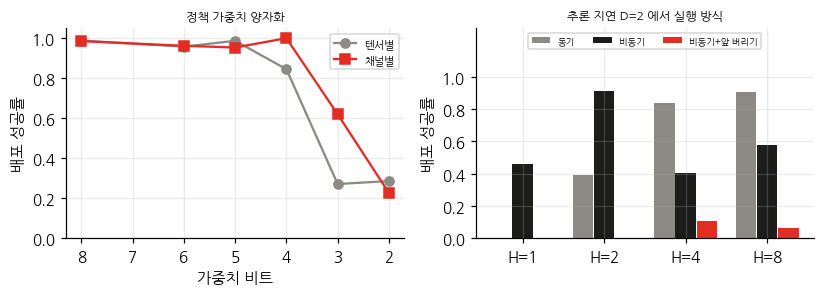

In [18]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(7.6, 2.8))
for per, col, mk, lab in (("tensor", GREY, "o", "텐서별"),
                          ("ch", RED, "s", "채널별")):
    a1.plot(BITS, [QA[(per, b, "배포")] for b in BITS], color=col,
            marker=mk, label=lab)
a1.invert_xaxis()
a1.set_xlabel("가중치 비트")
a1.set_ylabel("배포 성공률")
a1.set_ylim(0, 1.05)
a1.legend(fontsize=7)
a1.set_title("정책 가중치 양자화", fontsize=8)
x = np.arange(len(HS))
for j, (md, col) in enumerate((("sync", GREY), ("naive", INK),
                               ("skip", RED))):
    a2.bar(x + (j - 1) * .26, [GRID[(2, md, H)][0] for H in HS],
           .25, color=col, label=MODES[md])
a2.set_xticks(x, [f"H={H}" for H in HS])
a2.set_ylim(0, 1.3)
a2.set_yticks([0, .2, .4, .6, .8, 1.])
a2.set_ylabel("배포 성공률")
a2.set_title("추론 지연 D=2 에서 실행 방식", fontsize=8)
a2.legend(fontsize=6, loc="upper center", ncol=3)
plt.tight_layout()
plt.show()

## 산출물

In [19]:
torch.save(CH[H2], "policy/chunk_v1.pt")
out = {"quant_latency": {f"{'int8' if q else 'fp32'}-"
                         f"{'load' if l else 'idle'}":
                         dict(zip(("p50", "p99", "max"),
                                  [round(v, 2) for v in pct(ms)]))
                         for (q, l), ms in MS.items()},
       "quant_accuracy": {f"{p}-{b}-{c}": round(v, 3)
                          for (p, b, c), v in QA.items()},
       "grid": {f"D{D}-{md}-H{H}": round(v[0], 3)
                for (D, md, H), v in GRID.items()},
       "stack": {k: {"success": round(float(np.mean(v[0])), 3),
                     "cycle": round(v[1], 1),
                     "infer_per_step": round(v[2], 3)}
                 for k, v in ST.items()},
       "chunk_H": H2}
os.makedirs("runtime", exist_ok=True)
with open("runtime/chunk.json", "w") as f:
    json.dump(out, f, ensure_ascii=False, indent=1)
save_log("report/ch14_log.csv", LOG)
print("policy/chunk_v1.pt, runtime/chunk.json 저장")
print(f"report/ch14_log.csv  판별 로그 {len(LOG):,}줄")

policy/chunk_v1.pt, runtime/chunk.json 저장
report/ch14_log.csv  판별 로그 19,776줄
